In [3]:
import torch 
from torch import nn, Tensor
import tqdm
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import numpy as np
import random

def set_all_seeds(seed=42):
    random.seed(seed)
    
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) 
    
set_all_seeds(42)

def create_model_checkpoint(model_class, model):
    checkpoint = model_class()
    checkpoint.load_state_dict(model.state_dict())
    return checkpoint

def kl_2d(data_1, data_2, lim=1.2, bins=50):
    data_1 = data_1.cpu().detach().numpy() if data_1.is_cuda else data_1.detach().numpy()
    data_2 = data_2.cpu().detach().numpy() if data_2.is_cuda else data_2.detach().numpy()
    
    data_1 = np.clip(data_1, -lim, lim)
    data_2 = np.clip(data_2, -lim, lim)
    
    hist_1, x_edges, y_edges = np.histogram2d(
        data_1[:, 0], data_1[:, 1], bins=bins, range=[[-lim, lim], [-lim, lim]])
    hist_2, _, _ = np.histogram2d(
        data_2[:, 0], data_2[:, 1], bins=bins, range=[[-lim, lim], [-lim, lim]])
    
    hist_1 = hist_1 / np.sum(hist_1)
    hist_2 = hist_2 / np.sum(hist_2)
    
    eps = 1e-10
    hist_1 = hist_1 + eps
    hist_2 = hist_2 + eps
    
    # KL(P||Q) = sum(P * log(P/Q))
    kl_divergence = np.sum(hist_1 * np.log(hist_1 / hist_2))
    
    return kl_divergence

class Flow(nn.Module):
    def __init__(self, dim: int = 2, h: int = 24):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, h, bias=False), nn.ELU(),
            nn.Linear(h, h, bias=False), nn.ELU(),            
            nn.Linear(h, dim, bias=False))
    
    def forward(self, t: Tensor, x_t: Tensor) -> Tensor:
        return self.net(torch.cat((t, x_t), -1))
    
    def step(self, x_t: Tensor, t_start: Tensor, t_end: Tensor) -> Tensor:
        t_start = t_start.view(1, 1).expand(x_t.shape[0], 1)
        return x_t + (t_end - t_start) * self(
            t=t_start + (t_end - t_start) / 2, 
            x_t=x_t + self(x_t=x_t, t=t_start) * (t_end - t_start) / 2
        )

moon_scale = 0.5  
moon_rotation = 45 
moon_translation = [0.25, 0.25] 

guass_scale = 0.4
gauss_mean1 = [0, -guass_scale] 
gauss_mean2 = [-guass_scale, 0] 
gauss_cov1 = [[0.1*guass_scale, 0], [0, 0.025*guass_scale]] 
gauss_cov2 = [[0.025*guass_scale, 0], [0, 0.1*guass_scale]] 
gauss_means = [gauss_mean1, gauss_mean2]  
gauss_covs = [gauss_cov1, gauss_cov2] 

def generate_x0(n_samples=256):
    gauss = np.random.multivariate_normal([-0., -0.], [[0.1, 0], [0, 0.1]], n_samples)
    return torch.tensor(gauss, dtype=torch.float32)

def generate_x1(n_samples=256):
    X, y = make_moons(n_samples=n_samples*2, noise=0.01)
    X_moon = X[y == 0]
    
    theta = np.radians(moon_rotation)
    rot_matrix = np.array([[np.cos(theta), -np.sin(theta)], 
                           [np.sin(theta), np.cos(theta)]])
    X_moon = moon_scale * X_moon @ rot_matrix
    
    X_moon += moon_translation
    return torch.tensor(X_moon, dtype=torch.float32)

100%|██████████| 10000/10000 [00:11<00:00, 906.11it/s]


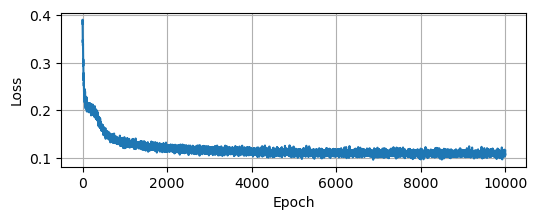

Final KL divergence: 0.6554465976297718


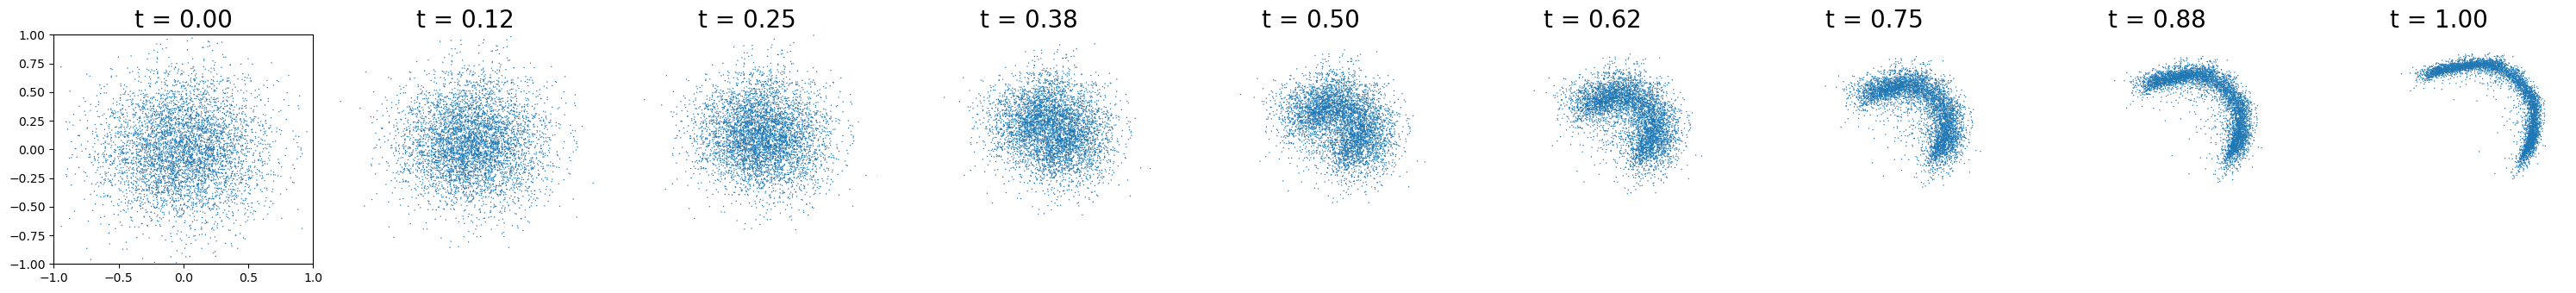

In [4]:
model = Flow()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()

batch_size = 1024
loss_history = []

for epoch in tqdm.tqdm(range(10000)):
    x_0 = generate_x0(n_samples=batch_size)
    x_1 = generate_x1(n_samples=batch_size)
    
    t = torch.rand(len(x_0), 1)
    x_t = (1 - t) * x_0 + t * x_1
    dx_t = (x_1 - x_0)

    optimizer.zero_grad()
    loss = loss_fn(model(t=t, x_t=x_t), dx_t)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    
    loss_history.append(loss.item())

    with torch.no_grad():
        for param in model.parameters():
            param.clamp_(-2, 2)

plt.figure(figsize=(6, 2))
plt.plot(loss_history); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(True); plt.show()

n_samples = 5000
x = generate_x0(n_samples=n_samples)
n_steps = 8
fig, axes = plt.subplots(1, n_steps + 1, figsize=(30, 3.5), sharex=True, sharey=True)
time_steps = torch.linspace(0, 1.0, n_steps + 1)

axes[0].scatter(x.detach()[:, 0], x.detach()[:, 1], s=1, edgecolors='none')
axes[0].set_title(f't = {time_steps[0]:.2f}', fontsize=20)

plot_lim = 1
axes[0].set_xlim(-plot_lim, plot_lim)
axes[0].set_ylim(-plot_lim, plot_lim)

for i in range(n_steps):
    x = model.step(x_t=x, t_start=time_steps[i], t_end=time_steps[i + 1])
    axes[i + 1].scatter(x.detach()[:, 0], x.detach()[:, 1], s=1, edgecolors='none')
    axes[i + 1].set_title(f't = {time_steps[i + 1]:.2f}', fontsize=20)
    axes[i + 1].set_axis_off()

print(f'Final KL divergence: {kl_2d(generate_x1(n_samples=n_samples), x, lim=1, bins=50)}')

plt.tight_layout()
plt.show()